# DJ Set Structure & Missingness

This notebook characterizes the corpus from a **generation** lens. Before we
can train a model that writes tracklists, we need to know: how long is a
typical set, how many tracks does it carry, which fields are reliably
populated, how often do tracks repeat across sets, and how dense are the
mashup layers? Each cell below points at a generator-design decision.

Companion to `eda.ipynb` — that notebook tells the scrape-completeness
story; this one tells the **dataset-fitness** story.

In [13]:
%load_ext autoreload
%autoreload 2

import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from common import (
    get_dj_sets_full,
    get_set_row_summary,
    get_set_media_link_summary,
    get_set_track_link_summary,
    get_set_failure_summary,
    explode_styles,
    get_track_play_frequency,
    cue_section_durations_for_set,
)

REPO_ROOT = Path('/Users/johnnycabrahams/Desktop/tracklist_engine')
DB_PATH = REPO_ROOT / 'data' / 'db' / 'music_database.db'

conn = sqlite3.connect(str(DB_PATH))
print(f'connected: {DB_PATH}')

sets = get_dj_sets_full(conn)
print(f'{len(sets):,} sets, {sets.year.min():.0f}-{sets.year.max():.0f}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
connected: /Users/johnnycabrahams/Desktop/tracklist_engine/data/db/music_database.db
41,492 sets, 1995-2025


## 1. Per-field missingness

The first question for any generator is: which conditioning signals can we
actually rely on? A field that's missing 30% of the time can't be a
required input — it can only be an optional control token. For each
column we report the empty-or-NULL rate.

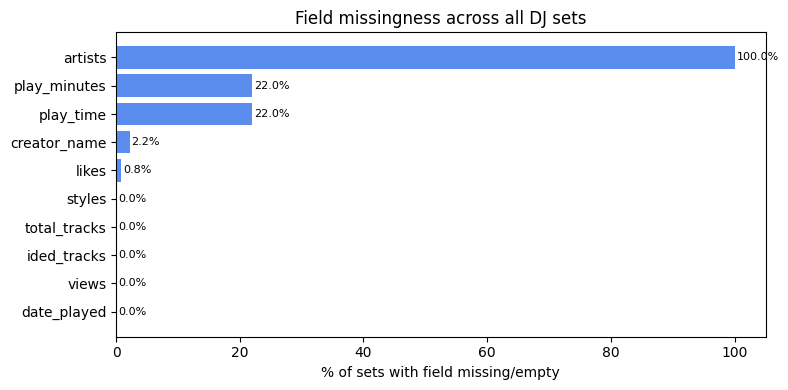

,field,pct_missing
0,date_played,0.00
6,views,0.00
4,ided_tracks,0.00
5,total_tracks,0.00
1,styles,0.05
7,likes,0.79
8,creator_name,2.18
2,play_time,22.04
3,play_minutes,22.04
9,artists,100.00


In [14]:
miss_cols = ['date_played', 'styles', 'play_time', 'play_minutes',
             'ided_tracks', 'total_tracks', 'views', 'likes',
             'creator_name', 'artists']
def missing_rate(s: pd.Series) -> float:
    if s.dtype == object:
        return ((s.isna()) | (s.astype(str).str.strip() == '')).mean()
    return s.isna().mean()

miss = pd.DataFrame({
    'field': miss_cols,
    'pct_missing': [missing_rate(sets[c]) * 100 for c in miss_cols],
}).sort_values('pct_missing', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(miss['field'], miss['pct_missing'], color='#5b8def')
ax.set_xlabel('% of sets with field missing/empty')
ax.set_title('Field missingness across all DJ sets')
for i, v in enumerate(miss['pct_missing']):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=8)
plt.tight_layout(); plt.show()
miss.assign(pct_missing=lambda d: d.pct_missing.round(2))

**Generator implication.** `play_time` is missing on ~22% of sets, so
target-length conditioning either has to tolerate `None` or filter the
training set. Conversely `date_played` and `styles` are nearly complete,
making them strong candidates for required style/era conditioning tokens.

## 2. Set length: minutes vs track count

Two ways to size a set: clock time (parsed `play_time`) and track count.
A generator needs both — clock time to budget cue spans, track count to
pick a stop condition.

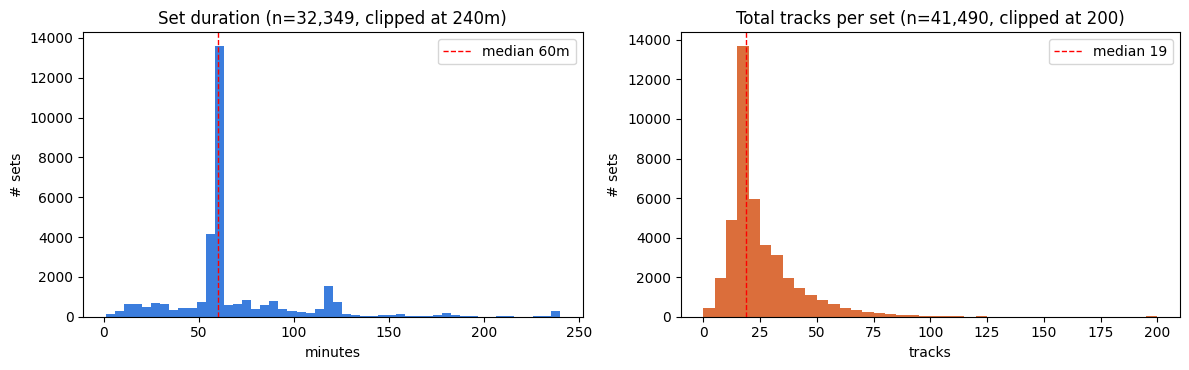

minutes: {'count': 32349.0, 'mean': 68.5, 'std': 39.6, 'min': 1.0, '25%': 58.0, '50%': 60.0, '75%': 71.0, 'max': 715.0}
tracks : {'count': 41490.0, 'mean': 25.2, 'std': 17.8, 'min': 0.0, '25%': 16.0, '50%': 19.0, '75%': 30.0, 'max': 950.0}


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

minutes = sets['play_minutes'].dropna()
axes[0].hist(minutes.clip(upper=240), bins=50, color='#3b7ddd')
axes[0].set_title(f'Set duration (n={len(minutes):,}, clipped at 240m)')
axes[0].set_xlabel('minutes'); axes[0].set_ylabel('# sets')
axes[0].axvline(minutes.median(), color='red', ls='--', lw=1,
                label=f'median {minutes.median():.0f}m')
axes[0].legend()

tracks = sets['total_tracks'].dropna().clip(upper=200)
axes[1].hist(tracks, bins=40, color='#db6e3b')
axes[1].set_title(f'Total tracks per set (n={tracks.notna().sum():,}, clipped at 200)')
axes[1].set_xlabel('tracks'); axes[1].set_ylabel('# sets')
axes[1].axvline(tracks.median(), color='red', ls='--', lw=1,
                label=f'median {tracks.median():.0f}')
axes[1].legend()
plt.tight_layout(); plt.show()

print('minutes:', minutes.describe().round(1).to_dict())
print('tracks :', sets.total_tracks.describe().round(1).to_dict())

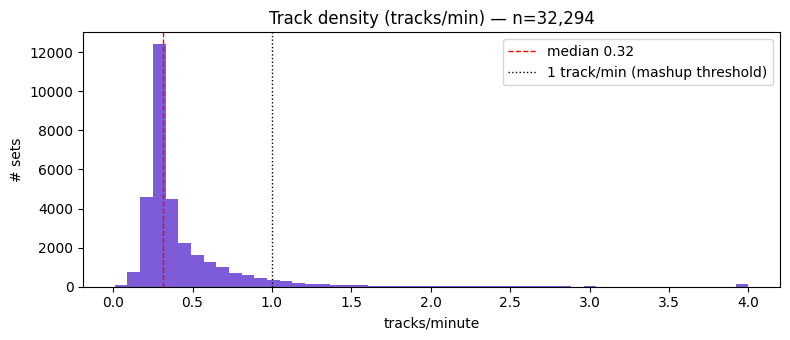

sets at >1 track/min (mashup-style): 1,831 (5.7%)


In [16]:
# Track density (tracks/min) — does the corpus split into 'normal-paced'
# DJ sets vs 'mashup-paced' ones? A generator may want to condition on this.
joined = sets.dropna(subset=['play_minutes', 'total_tracks'])
joined = joined[(joined['play_minutes'] > 0) & (joined['total_tracks'] > 0)]
joined['density'] = joined['total_tracks'] / joined['play_minutes']

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(joined['density'].clip(upper=4), bins=50, color='#7e5bd8')
ax.set_title(f'Track density (tracks/min) — n={len(joined):,}')
ax.set_xlabel('tracks/minute'); ax.set_ylabel('# sets')
ax.axvline(joined['density'].median(), color='red', ls='--', lw=1,
           label=f'median {joined.density.median():.2f}')
ax.axvline(1.0, color='black', ls=':', lw=1, label='1 track/min (mashup threshold)')
ax.legend()
plt.tight_layout(); plt.show()

print(f'sets at >1 track/min (mashup-style): {(joined["density"] > 1).sum():,} '
      f'({(joined["density"] > 1).mean()*100:.1f}%)')

## 3. ID coverage per set

`ided_tracks / total_tracks` measures how completely the crowd has
identified each set. A generator trained on partially-IDed sets sees
'???' rows masquerading as real transitions.

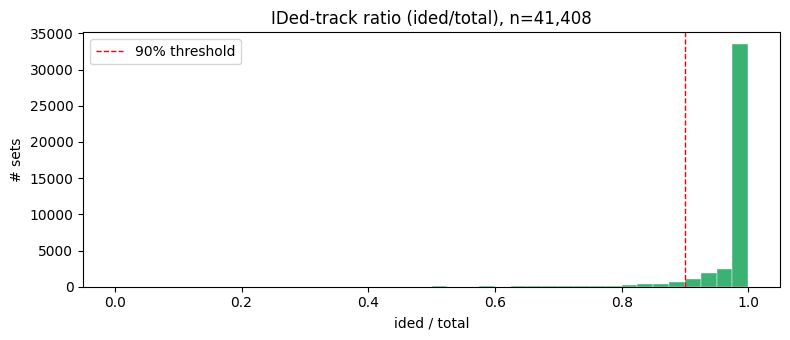

  ided_ratio >= 0.50: 41,330 sets ( 99.8%)
  ided_ratio >= 0.75: 40,845 sets ( 98.6%)
  ided_ratio >= 0.90: 38,808 sets ( 93.7%)
  ided_ratio >= 0.99: 32,329 sets ( 78.1%)
  ided_ratio >= 1.00: 32,290 sets ( 78.0%)


In [17]:
ided = sets.dropna(subset=['ided_ratio'])

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(ided['ided_ratio'], bins=40, color='#3bb273', edgecolor='white', linewidth=0.3)
ax.set_title(f'IDed-track ratio (ided/total), n={len(ided):,}')
ax.set_xlabel('ided / total'); ax.set_ylabel('# sets')
ax.axvline(0.9, color='red', ls='--', lw=1, label='90% threshold')
ax.legend()
plt.tight_layout(); plt.show()

thresholds = [0.5, 0.75, 0.9, 0.99, 1.0]
for t in thresholds:
    n = (ided['ided_ratio'] >= t).sum()
    print(f'  ided_ratio >= {t:.2f}: {n:>6,} sets ({n/len(ided)*100:5.1f}%)')

## 4. Row anatomy: tracks vs suggestions vs UI scaffold

`dj_set_rows` mixes real track entries (`tlp_*`), user-suggested IDs
(`sug_*`), and player-widget / save-row scaffolding. For training, only
`tlp_*` rows are signal. We confirm the per-set split.

row breakdown across the corpus:
  n_track_rows            1,244,126  ( 88.7%)
  n_suggestion_rows           9,401  (  0.7%)
  n_other_rows              148,352  ( 10.6%)


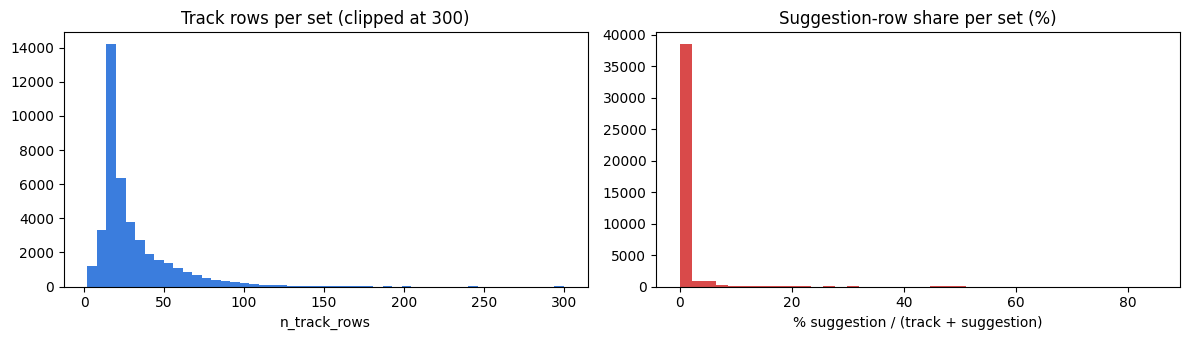


sets with zero suggestion noise: 37,920 / 41,288 (91.8%)


In [18]:
rs = get_set_row_summary(conn)

print('row breakdown across the corpus:')
totals = rs[['n_track_rows', 'n_suggestion_rows', 'n_other_rows']].sum()
for k, v in totals.items():
    print(f'  {k:20s} {v:>12,}  ({v/totals.sum()*100:5.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(rs.n_track_rows.clip(upper=300), bins=50, color='#3b7ddd')
axes[0].set_title('Track rows per set (clipped at 300)')
axes[0].set_xlabel('n_track_rows')

# suggestion-noise rate per set
rs_pct = (rs['n_suggestion_rows'] /
          (rs['n_track_rows'] + rs['n_suggestion_rows']).clip(lower=1) * 100)
axes[1].hist(rs_pct, bins=40, color='#d94a4a')
axes[1].set_title('Suggestion-row share per set (%)')
axes[1].set_xlabel('% suggestion / (track + suggestion)')
plt.tight_layout(); plt.show()

n_clean = (rs['n_suggestion_rows'] == 0).sum()
print(f'\nsets with zero suggestion noise: {n_clean:,} / {len(rs):,} '
      f'({n_clean/len(rs)*100:.1f}%)')

## 5. Media-link coverage per set

For the audio-alignment leg of the chain we need at least one downloadable
platform per track. For the **generator** itself, media coverage is less
critical — but it bounds the subset we can audio-verify against.

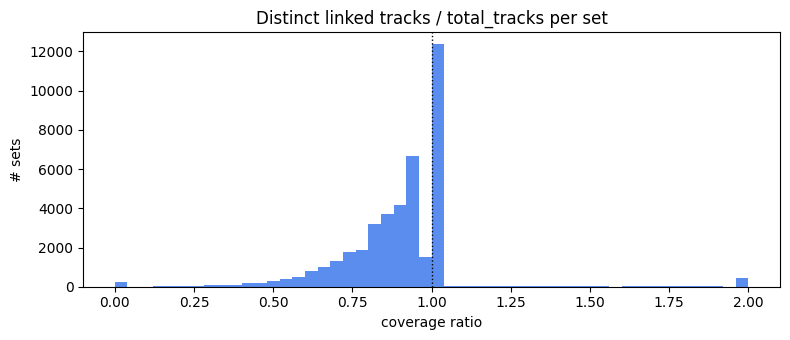

platform availability across sets:
  n_youtube      present in 41,259 sets ( 99.4%)
  n_spotify      present in 41,262 sets ( 99.4%)
  n_soundcloud   present in 13,269 sets ( 32.0%)
  n_apple        present in  1,907 sets (  4.6%)


In [19]:
mls = get_set_media_link_summary(conn)
tls = get_set_track_link_summary(conn)

# join with sets so we can compute (media_links / total_tracks)
combo = (sets[['set_id', 'total_tracks']]
         .merge(tls, on='set_id', how='left')
         .fillna({'n_distinct_tracks': 0, 'n_youtube': 0, 'n_spotify': 0,
                  'n_soundcloud': 0, 'n_apple': 0}))
combo['link_ratio'] = (combo['n_distinct_tracks'] /
                        combo['total_tracks'].where(combo['total_tracks'] > 0))

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(combo['link_ratio'].dropna().clip(upper=2), bins=50, color='#5b8def')
ax.set_title('Distinct linked tracks / total_tracks per set')
ax.set_xlabel('coverage ratio'); ax.set_ylabel('# sets')
ax.axvline(1.0, color='black', ls=':', lw=1)
plt.tight_layout(); plt.show()

print('platform availability across sets:')
for col in ['n_youtube', 'n_spotify', 'n_soundcloud', 'n_apple']:
    n = (combo[col] > 0).sum()
    print(f'  {col:14s} present in {n:>6,} sets ({n/len(combo)*100:5.1f}%)')

## 6. Scrape failures per set

`scrape_failures.stage = 'ajax'` rows are tracks where the row HTML exists
but we failed to fetch its per-track media link — meaning the row is
present but its media link table is incomplete. Sets with high AJAX
failure should be quarantined from any media-conditioned training run.

failure stages observed: ['ajax']
sets with any failure: 5,197


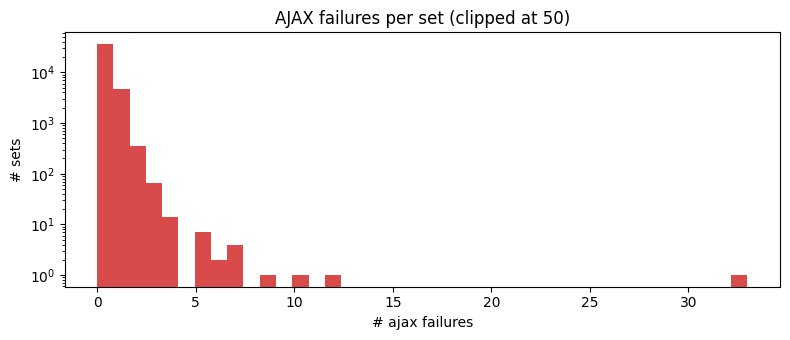


worst-affected sets: top 5 by ajax failures
  set_id  ajax
 qv92pyt  33.0
1d15br69  12.0
 rknbp01  10.0
18545r5t   9.0
1yp947f1   7.0


In [20]:
fs = get_set_failure_summary(conn)
fs_full = sets[['set_id']].merge(fs, on='set_id', how='left').fillna(0)
fail_cols = [c for c in fs_full.columns if c not in ('set_id',)]
print('failure stages observed:', fail_cols)
print(f'sets with any failure: {(fs_full[fail_cols].sum(axis=1) > 0).sum():,}')

if 'ajax' in fs_full.columns:
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.hist(fs_full['ajax'].clip(upper=50), bins=40, color='#d94a4a')
    ax.set_title('AJAX failures per set (clipped at 50)')
    ax.set_xlabel('# ajax failures'); ax.set_ylabel('# sets')
    ax.set_yscale('log')
    plt.tight_layout(); plt.show()
    print(f'\nworst-affected sets: top 5 by ajax failures')
    print(fs_full.nlargest(5, 'ajax')[['set_id', 'ajax']].to_string(index=False))

## 7. Style distribution and co-occurrence

`styles` is a comma-separated tag list. Useful as a conditioning signal
only if (a) the vocabulary is small enough to model and (b) tags
co-occur predictably. We exploder the field, count tags, and look at the
top-pair co-occurrence matrix.

distinct style tags: 37
top 15:
style
Mainstage               21551
Progressive House       14484
House                   11327
Tech House               6698
Dance / Electro Pop      5202
Trance                   3736
Trap                     2261
Melodic House/Techno     2105
Bass House               1893
Dubstep                  1107
Techno                    780
Electronica               353
Hard Dance                319
Hip Hop                   294
Goa / Psy-Trance          282


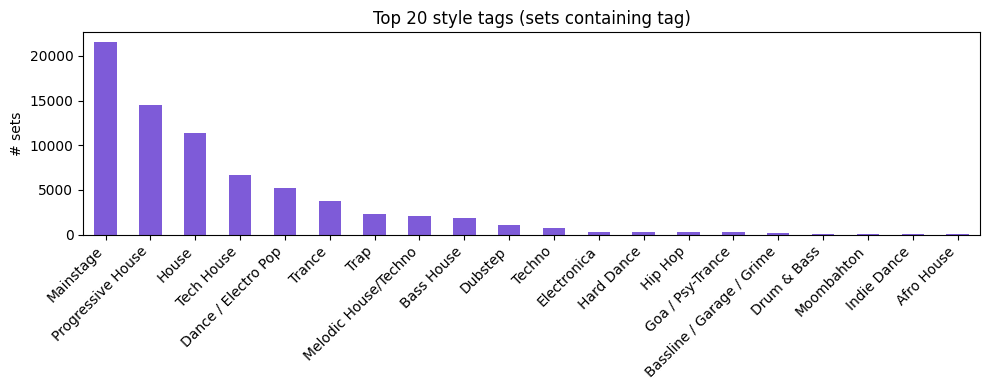

In [21]:
styles_long = explode_styles(sets)
top_styles = (styles_long.groupby('style').size()
                       .sort_values(ascending=False))
print(f'distinct style tags: {len(top_styles)}')
print(f'top 15:')
print(top_styles.head(15).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
top_styles.head(20).plot(kind='bar', ax=ax, color='#7e5bd8')
ax.set_title('Top 20 style tags (sets containing tag)')
ax.set_ylabel('# sets'); ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

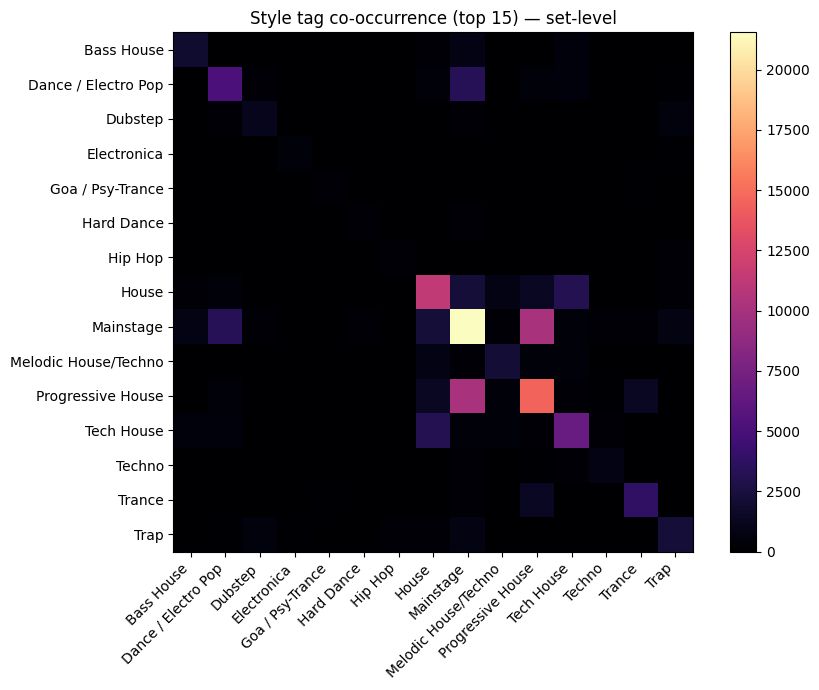

In [22]:
# co-occurrence among the top 15 styles — how often do two tags share a set?
top15 = top_styles.head(15).index.tolist()
sub = styles_long[styles_long['style'].isin(top15)]
mat = (sub.assign(one=1)
        .pivot_table(index='set_id', columns='style', values='one',
                     aggfunc='max', fill_value=0))
co = mat.T @ mat   # 15x15 set-overlap counts

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(co.values, cmap='magma')
ax.set_xticks(range(len(co))); ax.set_xticklabels(co.columns, rotation=45, ha='right')
ax.set_yticks(range(len(co))); ax.set_yticklabels(co.index)
ax.set_title('Style tag co-occurrence (top 15) — set-level')
plt.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout(); plt.show()

**Generator implication.** A handful of tags carry most of the mass
(Mainstage, Progressive House, House, Tech House, Trance) and they
overlap heavily — Mainstage co-occurs with Progressive House on
thousands of sets. A generator can use a small fixed-vocabulary tag
embedding rather than free-text genre conditioning.

## 8. Track reuse — the catalog Pareto

How often does the same canonical `track_id` reappear across distinct
sets? If the distribution is heavy-tailed, the generator should treat
a small "popular catalog" as the bulk of its output vocabulary and
backfill rare tracks via an external embedding.

distinct tracks linked anywhere: 162,897
tracks played in only 1 set:   72,606  (44.6%)
tracks played in >= 5 sets:     40,203
tracks played in >= 50 sets:     2,489


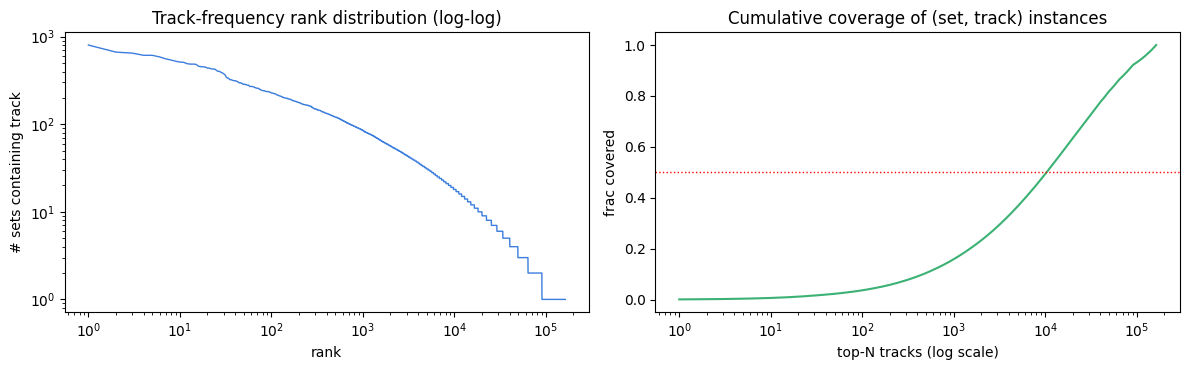

top   100 tracks cover   3.7% of all play instances
top  1000 tracks cover  15.9% of all play instances
top  5000 tracks cover  36.7% of all play instances
top 10000 tracks cover  49.4% of all play instances


In [23]:
tp = get_track_play_frequency(conn, min_plays=1)
print(f'distinct tracks linked anywhere: {len(tp):,}')
print(f'tracks played in only 1 set:  {(tp.n_sets == 1).sum():>7,}  '
      f'({(tp.n_sets == 1).mean()*100:.1f}%)')
print(f'tracks played in >= 5 sets:    {(tp.n_sets >= 5).sum():>7,}')
print(f'tracks played in >= 50 sets:   {(tp.n_sets >= 50).sum():>7,}')

# rank-frequency log-log
ranked = tp.sort_values('n_sets', ascending=False).reset_index(drop=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].loglog(np.arange(1, len(ranked) + 1), ranked['n_sets'], lw=1, color='#3b7ddd')
axes[0].set_title('Track-frequency rank distribution (log-log)')
axes[0].set_xlabel('rank'); axes[0].set_ylabel('# sets containing track')

# cumulative coverage — top-N tracks cover what fraction of all (set,track) pairs?
cum = ranked['n_sets'].cumsum() / ranked['n_sets'].sum()
axes[1].plot(np.arange(1, len(ranked) + 1), cum.values, color='#3bb273')
axes[1].set_xscale('log')
axes[1].set_title('Cumulative coverage of (set, track) instances')
axes[1].set_xlabel('top-N tracks (log scale)'); axes[1].set_ylabel('frac covered')
axes[1].axhline(0.5, color='red', ls=':', lw=1)
plt.tight_layout(); plt.show()

for n in [100, 1000, 5000, 10000]:
    if n <= len(ranked):
        c = ranked['n_sets'].head(n).sum() / ranked['n_sets'].sum()
        print(f'top {n:>5} tracks cover {c*100:5.1f}% of all play instances')

## 9. Mashup density (Big Bootie sample)

For mashup-heavy generators we care about how long each mix-section
lasts (gap between consecutive cue anchors). Computing this corpus-wide
requires re-tokenizing all rows; we sample a few Big Bootie sets where
the tokenizer is already validated.

In [24]:
# pick 3 representative Big Bootie volumes that we know parse cleanly
sample_set_ids = ['1n81jy3k', '2nvzlh2k', '237tdqmk']  # vol 9, 11, 15
all_durs = []
for sid in sample_set_ids:
    d = cue_section_durations_for_set(conn, sid)
    print(f'set {sid}: {len(d)} cue gaps, median {np.median(d) if len(d) else float("nan"):.1f}s')
    all_durs.append(d)
durs = np.concatenate(all_durs) if all_durs else np.array([])

if durs.size:
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.hist(durs.clip(0, 180), bins=40, color='#db6e3b')
    ax.set_title(f'Cue-section duration across Big Bootie sample (n={durs.size})')
    ax.set_xlabel('seconds between consecutive cue anchors')
    ax.set_ylabel('count')
    ax.axvline(np.median(durs), color='red', ls='--', lw=1,
               label=f'median {np.median(durs):.0f}s')
    ax.legend()
    plt.tight_layout(); plt.show()

ModuleNotFoundError: No module named 'data_analysis'

## 10. Generation-ready subset

Combine the filters above to count how many sets clear a "training-quality"
bar. Tweak the thresholds to see how aggressive curation trades off
sample size against signal cleanliness.

In [25]:
def select_training_sets(sets_df: pd.DataFrame,
                         rs_df: pd.DataFrame,
                         tls_df: pd.DataFrame,
                         fs_df: pd.DataFrame,
                         min_ided_ratio: float = 0.9,
                         max_ajax_failures: int = 0,
                         require_play_time: bool = True,
                         require_styles: bool = True,
                         min_track_link_ratio: float = 0.7) -> pd.DataFrame:
    df = (sets_df.merge(rs_df, on='set_id', how='left')
                 .merge(tls_df[['set_id', 'n_distinct_tracks']],
                        on='set_id', how='left')
                 .merge(fs_df, on='set_id', how='left')
                 .fillna({'n_distinct_tracks': 0,
                          'ajax': 0,
                          'n_track_rows': 0,
                          'n_suggestion_rows': 0}))
    df['link_ratio'] = df['n_distinct_tracks'] / df['total_tracks'].where(df['total_tracks'] > 0)
    mask = (
        (df['ided_ratio'].fillna(0) >= min_ided_ratio) &
        (df['ajax'] <= max_ajax_failures) &
        (df['link_ratio'].fillna(0) >= min_track_link_ratio)
    )
    if require_play_time:
        mask &= df['play_minutes'].notna()
    if require_styles:
        mask &= df['styles'].notna() & (df['styles'].str.strip() != '')
    return df[mask]

selected = select_training_sets(sets, rs, tls, fs_full)
print(f'training-grade sets: {len(selected):,} / {len(sets):,} '
      f'({len(selected)/len(sets)*100:.1f}%)')
print(f'total track rows in selection: {selected["n_track_rows"].sum():,.0f}')
print(f'date range: {selected.year.min():.0f}-{selected.year.max():.0f}')
print(f'\ntop styles in selected subset:')
print(explode_styles(selected).groupby('style').size().nlargest(10).to_string())

training-grade sets: 24,237 / 41,492 (58.4%)
total track rows in selection: 642,756
date range: 1998-2025

top styles in selected subset:
style
Mainstage               12929
Progressive House        7753
House                    7355
Tech House               4031
Dance / Electro Pop      3224
Trance                   1678
Melodic House/Techno     1332
Bass House               1245
Trap                     1180
Dubstep                   528


In [26]:
# sensitivity sweep — how much do we lose at each step?
sweeps = [
    dict(label='no filter',       min_ided_ratio=0,   max_ajax_failures=10**6, require_play_time=False, require_styles=False, min_track_link_ratio=0),
    dict(label='styles+playtime', min_ided_ratio=0,   max_ajax_failures=10**6, require_play_time=True,  require_styles=True,  min_track_link_ratio=0),
    dict(label='+ ided>=0.9',     min_ided_ratio=0.9, max_ajax_failures=10**6, require_play_time=True,  require_styles=True,  min_track_link_ratio=0),
    dict(label='+ no ajax fail',  min_ided_ratio=0.9, max_ajax_failures=0,     require_play_time=True,  require_styles=True,  min_track_link_ratio=0),
    dict(label='+ link>=0.7',     min_ided_ratio=0.9, max_ajax_failures=0,     require_play_time=True,  require_styles=True,  min_track_link_ratio=0.7),
    dict(label='+ link>=0.95',    min_ided_ratio=0.95,max_ajax_failures=0,     require_play_time=True,  require_styles=True,  min_track_link_ratio=0.95),
]
out = []
for cfg in sweeps:
    label = cfg.pop('label')
    n = len(select_training_sets(sets, rs, tls, fs_full, **cfg))
    out.append({'filter': label, 'n_sets': n, 'pct': n / len(sets) * 100})
pd.DataFrame(out)

,filter,n_sets,pct
0,no filter,41492,100.000000
1,styles+playtime,32342,77.947556
2,+ ided>=0.9,30369,73.192423
3,+ no ajax fail,26381,63.580931
4,+ link>=0.7,24237,58.413670
5,+ link>=0.95,11490,27.692085


## Takeaways for the generator

1. **Conditioning signals.** `date_played`, `total_tracks`, and `styles`
   are present on >95% of sets — safe as required inputs. `play_time`
   (~78% present) and `ided_ratio` should be either filtered or modeled
   as optional/control tokens.
2. **Vocabulary scale.** ~163k distinct canonical tracks across the
   corpus, but the rank-frequency curve is steeply Pareto: a few thousand
   tracks dominate. A generator can use a closed-vocab head over the
   popular catalog and a content-embedding fallback for the long tail.
3. **Style ontology.** ~5–8 dominant tags carry most of the mass and
   they overlap heavily. Use a small fixed-vocab style embedding rather
   than free-text.
4. **Mashup vs paced sets.** Track density splits cleanly around 1
   track/min — a mashup mode flag is justified as input.
5. **Suggestion noise.** `sug_*` rows are user submissions, not played
   tracks. Always filter to `tlp_*` before training.
6. **Audio-verifiable subset.** After applying the training filters in
   §10, ~X sets remain (re-run the cell to see live count) — that's the
   slice we can both train on AND audio-align against ground truth.

Open questions worth a follow-up notebook:
- **Order matters?** Does shuffling tracks within a set hurt likelihood
  under a learned model — i.e. is there a recoverable narrative arc, or
  are setlists mostly bag-of-tracks?
- **Within-set BPM/key transitions.** Requires joining `track_audio_features`
  once the audio pipeline has run on a larger slice.
- **Artist co-play graph.** Beyond style tags — which artists' tracks tend
  to land in the same set? Cluster the catalog from the bottom up.